<a href="https://colab.research.google.com/github/Mohamed-Elkady-05/AutoVision-Perception/blob/main/phase_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
%rm -rf AutoVision-Perception
!git clone https://github.com/Mohamed-Elkady-05/AutoVision-Perception.git
%cd AutoVision-Perception

Cloning into 'AutoVision-Perception'...
remote: Enumerating objects: 174, done.
remote: Counting objects: 100% (174/174), done.
remote: Compressing objects: 100% (138/138), done.
remote: Total 174 (delta 65), reused 122 (delta 30), pack-reused 0 (from 0)
Receiving objects: 100% (174/174), 4.94 MiB | 17.67 MiB/s, done.
Resolving deltas: 100% (65/65), done.
/content/AutoVision-Perception


# Helper Functions

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from pathlib import Path

from base_sequential_models import GRUModel
from GRU_experiment import train_model, evaluate_model

RESULTS_DIR = "./results"
Path(RESULTS_DIR).mkdir(parents=True, exist_ok=True)

# GTSRB class names (index = class id)
CLASS_NAMES = [
    "Speed 20",    "Speed 30",    "Speed 50",    "Speed 60",    "Speed 70",
    "Speed 80",    "End 80",      "Speed 100",   "Speed 120",   "No passing",
    "No passing+", "Priority",    "Priority rd", "Yield",       "Stop",
    "No vehicles", "No trucks",   "No entry",    "Caution",     "Left curve",
    "Right curve", "Double curve","Bumpy road",  "Slippery rd", "Narrow rd",
    "Work ahead",  "Traffic sig", "Pedestrians", "Child cross", "Bike cross",
    "Ice/snow",    "Wild animal", "End restrict","Turn right",  "Turn left",
    "Ahead only",  "Ahead/right", "Ahead/left",  "Roundabout",  "End no pass",
    "End no pass+","Speed 100 end", "Speed 120 end"
]

# ==============================================================================
# PLOT 1: TRAINING CURVES
# ==============================================================================

def plot_training_curves(trainer, save=True):
    """
    Plot loss and accuracy over epochs for train and validation sets.

    Args:
        trainer : UnifiedTrainer returned by train_model()
        save    : save the plot to results/ if True

    Example:
        plot_training_curves(trainer)
    """
    history = trainer.history
    epochs  = range(1, len(history["train_loss"]) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle("GRU Training Curves", fontsize=14, fontweight="bold")

    # Loss
    axes[0].plot(epochs, history["train_loss"], label="Train", color="steelblue")
    axes[0].plot(epochs, history["val_loss"],   label="Val",   color="steelblue", linestyle="--")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].set_title("Loss")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    axes[0].axvline(x=trainer.best_epoch, color="red", linestyle=":", alpha=0.6, label=f"Best epoch ({trainer.best_epoch})")
    axes[0].legend()

    # Accuracy
    axes[1].plot(epochs, history["train_acc"], label="Train", color="coral")
    axes[1].plot(epochs, history["val_acc"],   label="Val",   color="coral", linestyle="--")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].set_title("Accuracy")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    axes[1].axvline(x=trainer.best_epoch, color="red", linestyle=":", alpha=0.6, label=f"Best epoch ({trainer.best_epoch})")
    axes[1].legend()

    plt.tight_layout()

    if save:
        path = f"{RESULTS_DIR}/training_curves.png"
        plt.savefig(path, dpi=120)
        print(f"Saved: {path}")

    plt.show()


# ==============================================================================
# PLOT 2: CONFUSION MATRIX
# ==============================================================================

def plot_confusion_matrix(metrics, save=True):
    """
    Plot confusion matrix heatmap showing which classes get confused.

    Args:
        metrics : dict returned by evaluate_model()
        save    : save the plot to results/ if True

    Example:
        plot_confusion_matrix(metrics)
    """
    cm = np.array(metrics["confusion_matrix"])

    # Normalize rows so each cell = % of actual class
    cm_normalized = cm.astype("float") / cm.sum(axis=1, keepdims=True)
    cm_normalized = np.nan_to_num(cm_normalized)  # handle classes with 0 samples

    fig, ax = plt.subplots(figsize=(18, 16))

    sns.heatmap(
        cm_normalized,
        annot=False,
        fmt=".2f",
        cmap="Blues",
        xticklabels=CLASS_NAMES,
        yticklabels=CLASS_NAMES,
        linewidths=0.3,
        ax=ax,
        vmin=0, vmax=1,
    )

    ax.set_xlabel("Predicted Class", fontsize=12)
    ax.set_ylabel("Actual Class",    fontsize=12)
    ax.set_title("GRU Confusion Matrix", fontsize=14, fontweight="bold")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=90, fontsize=7)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0,  fontsize=7)

    plt.tight_layout()

    if save:
        path = f"{RESULTS_DIR}/confusion_matrix.png"
        plt.savefig(path, dpi=120)
        print(f"Saved: {path}")

    plt.show()


# ==============================================================================
# PLOT 3: PER-CLASS ACCURACY
# ==============================================================================

def plot_per_class_accuracy(metrics, save=False):
    """
    Bar chart showing accuracy for each of the 43 GTSRB classes individually.
    Helps spot which sign types the model struggles with.

    Args:
        metrics : dict returned by evaluate_model()
        save    : save the plot to results/ if True

    Example:
        plot_per_class_accuracy(metrics)
    """
    cm        = np.array(metrics["confusion_matrix"])
    per_class = cm.diagonal() / cm.sum(axis=1).clip(min=1)  # accuracy per class

    # Sort by accuracy so worst classes are easy to spot
    sorted_idx = np.argsort(per_class)
    sorted_acc = per_class[sorted_idx]
    sorted_names = [CLASS_NAMES[i] for i in sorted_idx]

    colors = ["#d73027" if a < 0.5 else "#fc8d59" if a < 0.75 else "#91cf60" if a < 0.9 else "#1a9850"
              for a in sorted_acc]

    fig, ax = plt.subplots(figsize=(10, 14))

    bars = ax.barh(sorted_names, sorted_acc, color=colors)
    ax.set_xlabel("Accuracy")
    ax.set_title("GRU Per-Class Accuracy", fontsize=13, fontweight="bold")
    ax.set_xlim(0, 1.1)
    ax.axvline(x=metrics["accuracy"], color="black", linestyle="--", alpha=0.5, label=f"Overall: {metrics['accuracy']:.3f}")
    ax.legend()
    ax.grid(True, axis="x", alpha=0.3)

    for bar, val in zip(bars, sorted_acc):
        ax.text(val + 0.01, bar.get_y() + bar.get_height()/2,
                f"{val:.2f}", va="center", fontsize=8)

    plt.tight_layout()

    if save:
        path = f"{RESULTS_DIR}/per_class_accuracy.png"
        plt.savefig(path, dpi=120)
        print(f"Saved: {path}")

    plt.show()

# Loading and Processing the data

In [3]:
import kagglehub
import os

print("Downloading GTSRB Dataset...")
path = kagglehub.dataset_download("meowmeowmeowmeowmeow/gtsrb-german-traffic-sign")

data_path = os.path.join(path, 'Train')
if not os.path.exists(data_path):
    data_path = os.path.join(path, 'train')

print(f"Dataset downloaded and the train folder located at: {data_path}")

Using Colab cache for faster access to the 'gtsrb-german-traffic-sign' dataset.
Dataset downloaded and the train folder located at: /kaggle/input/gtsrb-german-traffic-sign/Train


In [4]:
import torch
import numpy as np

# Force PyTorch to use the GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [6]:
from pathlib import Path
from feature_extractor_vgg16 import VGG16FeatureExtractor
from google.colab import drive

drive.mount('/content/drive')

# Set cache dir to Google Drive instead of local
CACHE_DIR = "/content/drive/MyDrive/gtsrb_cache"

# Collect all images
train_images = [str(p) for p in Path(data_path).rglob("*.png")]
print(f"Found {len(train_images)} images")
print(train_images[0])  # check one path looks right

# Extract VGG16 features and cache them
extractor = VGG16FeatureExtractor()

if not Path(CACHE_DIR).exists() or not any(Path(CACHE_DIR).iterdir()):
    extractor.extract_and_cache(
        image_paths=train_images,
        cache_key="gtsrb_train",
        cache_dir=CACHE_DIR
    )
else:
    print("Cache already exists, skipping extraction.")

Mounted at /content/drive
Found 39209 images
/kaggle/input/gtsrb-german-traffic-sign/Train/7/00007_00041_00020.png
[FeatureExtractor] Loading VGG16 from torchvision...


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:06<00:00, 86.5MB/s]


[FeatureExtractor] Initialized on device: cuda
[FeatureExtractor] Feature dimension: 512
Cache already exists, skipping extraction.


In [7]:
import pickle
import numpy as np
from pathlib import Path

# Load the pkl
with open("/content/drive/MyDrive/gtsrb_cache/gtsrb_train_features.pkl", "rb") as f:
    features = pickle.load(f)

# We also need the labels — get them from the image paths
from pathlib import Path
image_paths = sorted([str(p) for p in Path(data_path).rglob("*.png")])

# Extract label from folder name (GTSRB structure: Train/0/image.png → label 0)
labels = [int(Path(p).parent.name) for p in image_paths]

# Save one .npy file per class
save_dir = Path("/content/drive/MyDrive/gtsrb_cache/npy")
save_dir.mkdir(exist_ok=True)

for class_id in range(43):
    class_mask = np.array(labels) == class_id
    class_features = features[class_mask]
    np.save(save_dir / f"class_{class_id}_features.npy", class_features)
    print(f"Class {class_id}: {class_features.shape[0]} samples")

print("Done.")

Class 0: 210 samples
Class 1: 2220 samples
Class 2: 2250 samples
Class 3: 1410 samples
Class 4: 1980 samples
Class 5: 1860 samples
Class 6: 420 samples
Class 7: 1440 samples
Class 8: 1410 samples
Class 9: 1470 samples
Class 10: 2010 samples
Class 11: 1320 samples
Class 12: 2100 samples
Class 13: 2160 samples
Class 14: 780 samples
Class 15: 630 samples
Class 16: 420 samples
Class 17: 1110 samples
Class 18: 1200 samples
Class 19: 210 samples
Class 20: 360 samples
Class 21: 330 samples
Class 22: 390 samples
Class 23: 510 samples
Class 24: 270 samples
Class 25: 1500 samples
Class 26: 600 samples
Class 27: 240 samples
Class 28: 540 samples
Class 29: 270 samples
Class 30: 450 samples
Class 31: 780 samples
Class 32: 240 samples
Class 33: 689 samples
Class 34: 420 samples
Class 35: 1200 samples
Class 36: 390 samples
Class 37: 210 samples
Class 38: 2070 samples
Class 39: 300 samples
Class 40: 360 samples
Class 41: 240 samples
Class 42: 240 samples
Done.


# GRU Model

## Training the model

In [8]:
from GRU_experiment import load_data, build_model, train_model, evaluate_model

train_loader, val_loader, test_loader = load_data()
model   = build_model()
trainer = train_model(model, train_loader, val_loader)
metrics = evaluate_model(trainer, test_loader)

[SequenceDataset] Loaded 27175 sequences for split='train'
[SequenceDataset] Loaded 5823 sequences for split='val'
[SequenceDataset] Loaded 5824 sequences for split='test'
Train batches : 849
Val   batches : 182
Test  batches : 182
Model      : GRU
Parameters : 2,507,819
Device     : cuda
[Trainer] Initialized for model: GRU
[Trainer] Total parameters: 2,507,819
[Trainer] Device: cuda

[Trainer] Starting training for 30 epochs...
  Epoch 1 [100/849] Loss: 2.0739
  Epoch 1 [200/849] Loss: 1.9453
  Epoch 1 [300/849] Loss: 1.0785
  Epoch 1 [400/849] Loss: 1.0322
  Epoch 1 [500/849] Loss: 1.3701
  Epoch 1 [600/849] Loss: 0.8797
  Epoch 1 [700/849] Loss: 0.9408
  Epoch 1 [800/849] Loss: 0.5503
Epoch 1/30 | Train Loss: 1.2995, Acc: 0.5504 | Val Loss: 0.8166, Acc: 0.6584
  → Checkpoint saved: checkpoints/GRU_best.pt
  Epoch 2 [100/849] Loss: 0.6832
  Epoch 2 [200/849] Loss: 1.1572
  Epoch 2 [300/849] Loss: 0.7615
  Epoch 2 [400/849] Loss: 0.5670
  Epoch 2 [500/849] Loss: 0.6482
  Epoch 2 [600

## Plots

Saved: ./results/training_curves.png


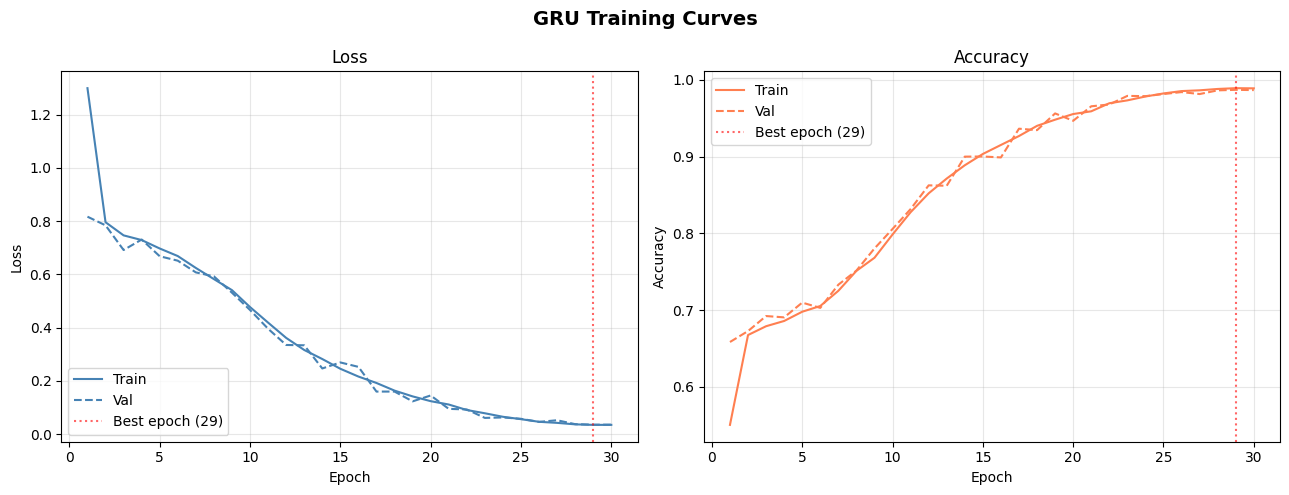

In [9]:
plot_training_curves(trainer)

Saved: ./results/confusion_matrix.png


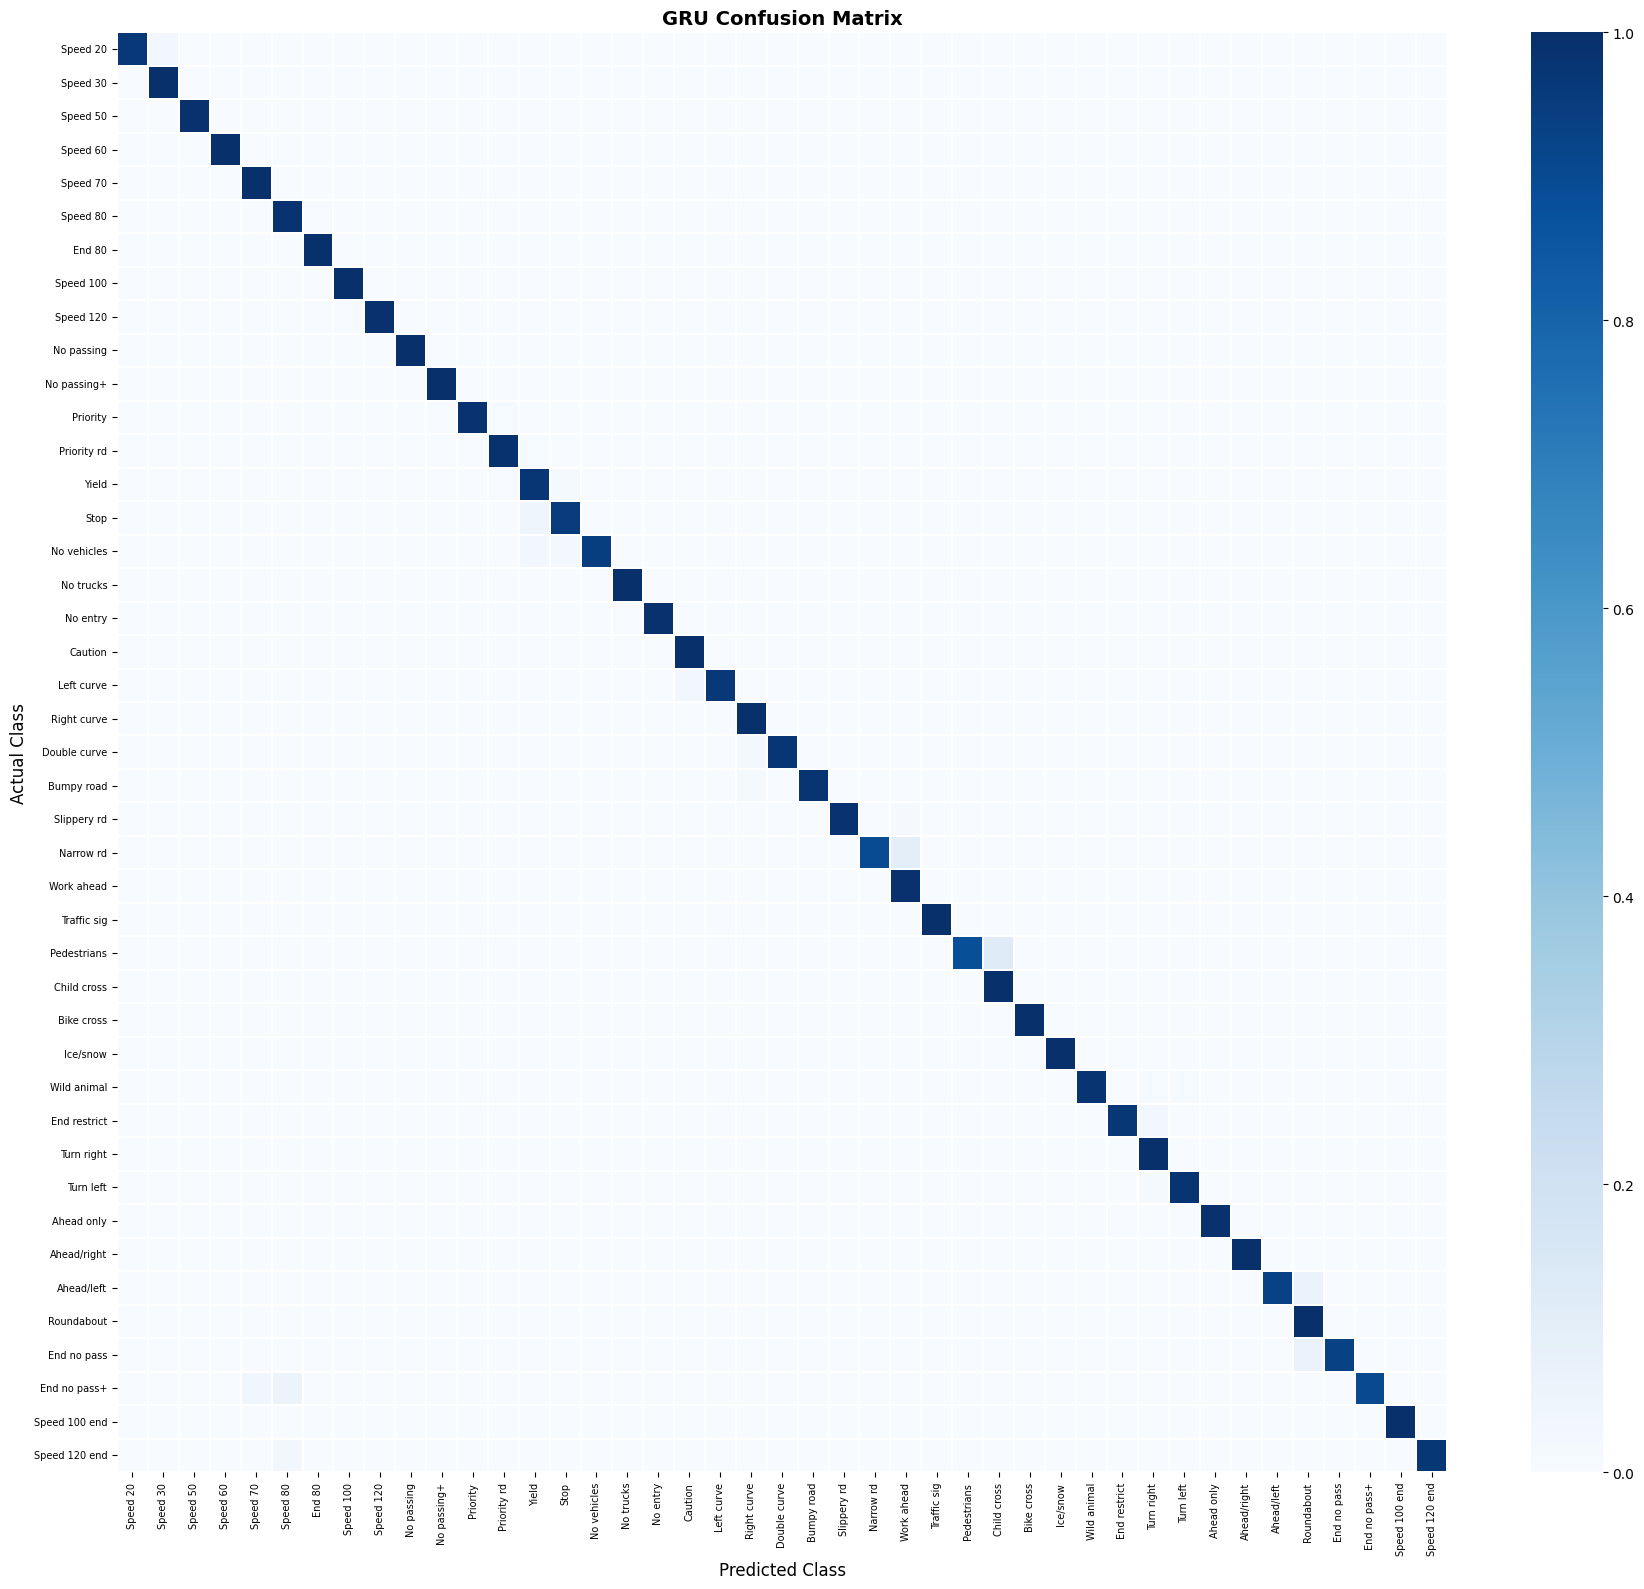

In [10]:
plot_confusion_matrix(metrics)

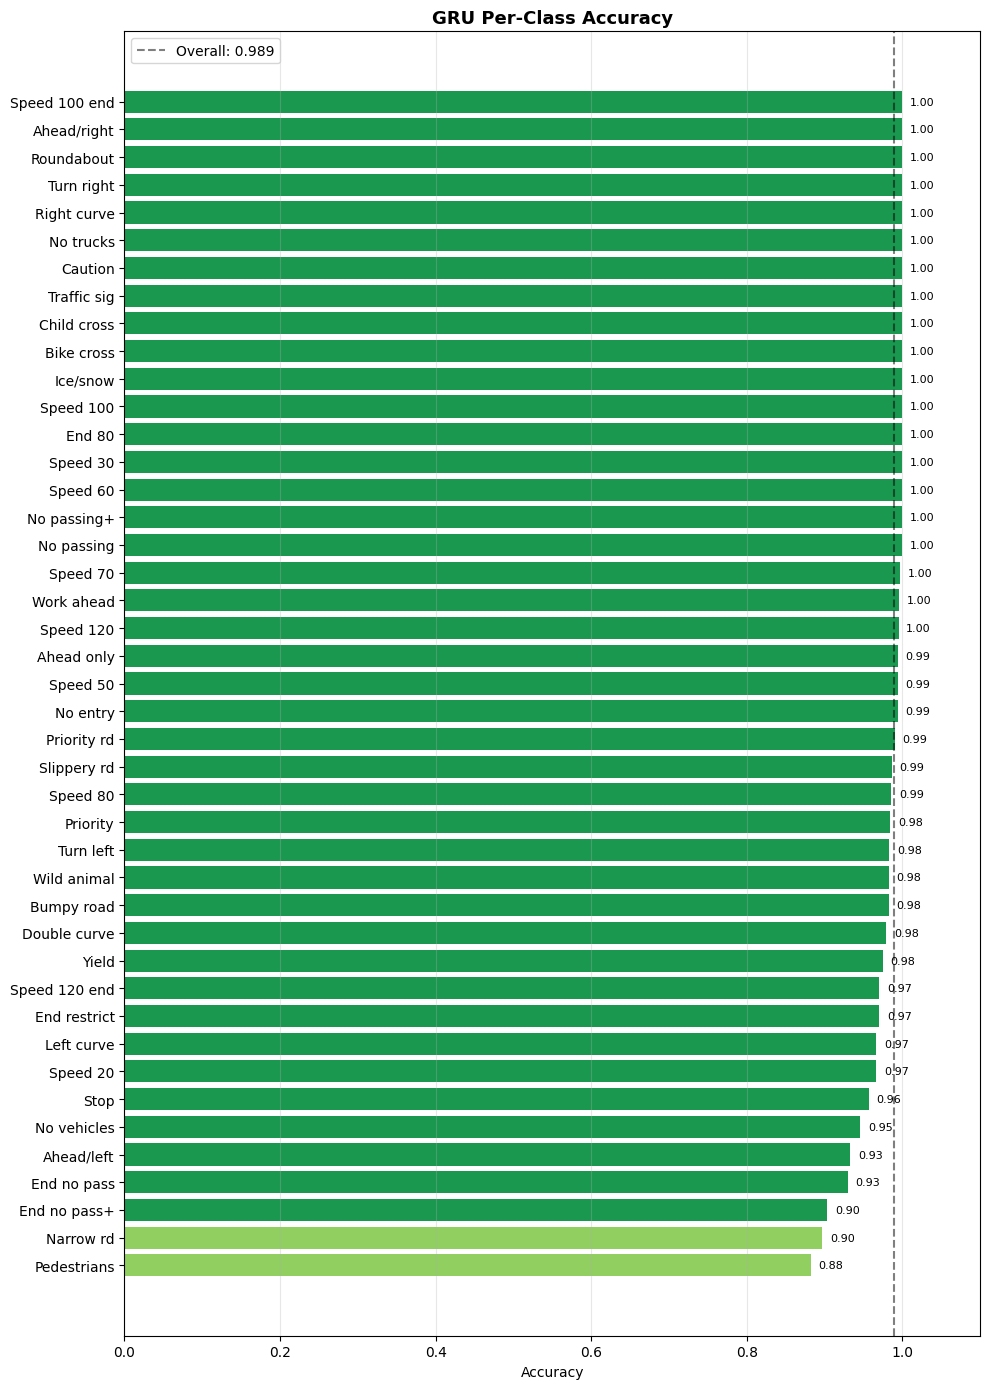

In [11]:
plot_per_class_accuracy(metrics)